# Training Pipeline Rollout Debug

This notebook will sequentially test three pipelines:

- `sac_her`
- `greedy`
- `greedy_bc_pretrain`

Each pipeline will do three things:

1. Run training / evaluation once.
2. Capture a complete rollout trajectory.
3. Generate GIF, step-by-step table, and final conclusion.

All outputs will be saved to `notebooks/artifacts/training_pipeline_rollout_debug/`.

In [1]:
from __future__ import annotations

import sys
from copy import deepcopy
from pathlib import Path

import pandas as pd
from IPython.display import Image, Markdown, display

PROJECT_ROOT = (
    Path.cwd().resolve().parent
    if Path.cwd().name == "notebooks"
    else Path.cwd().resolve()
)
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.training import (
    capture_rollout_trace,
    load_config,
    make_pipeline_config,
    run_named_pipeline,
    save_rollout_gif,
)

## Step 1. Load base config and create smoke test overrides for this notebook

Intentionally keep timesteps and demo count low for quick verification of the entire pipeline and GIF generation.

In [2]:
BASE_CONFIG = load_config(PROJECT_ROOT / "configs" / "smoke_test.yaml")
ARTIFACT_ROOT = (
    PROJECT_ROOT / "notebooks" / "artifacts" / "training_pipeline_rollout_debug"
)
ARTIFACT_ROOT.mkdir(parents=True, exist_ok=True)

COMMON_OVERRIDES = {
    "name": "training_pipeline_rollout_debug",
    "embedding": {"max_clues": 1200},
    "bc": {
        "demo_episodes": 4,
        "pretrain_epochs": 1,
        "batch_size": 32,
    },
    "training": {
        "total_timesteps": 80,
        "learning_starts": 20,
        "batch_size": 32,
        "net_arch": [128, 128],
    },
    "evaluation": {
        "episodes": 2,
        "deterministic": True,
    },
}

PIPELINES = ["sac_her", "greedy", "greedy_bc_pretrain"]
ARTIFACT_ROOT

PosixPath('/Users/sungtsewu/Desktop/temp_github/Codenames-Spymaster-RL/notebooks/artifacts/training_pipeline_rollout_debug')

## Step 2. Define shared runner

The key point is that the notebook is not bound to a specific agent type. As long as the agent produced by the pipeline supports `predict(...)` or `select_action(...)`, the same process can be reused.

In [3]:
def build_summary_row(result, trace, gif_path):
    trace_summary = trace.summary()
    return {
        "pipeline": result.pipeline_name,
        "agent": result.agent_label,
        "demo_transitions": result.demo_transitions,
        "eval_win_rate": round(result.agent_metrics["win_rate"], 3),
        "eval_assassin_rate": round(result.agent_metrics["assassin_rate"], 3),
        "trace_steps": trace_summary["steps"],
        "trace_total_reward": round(trace_summary["total_reward"], 3),
        "trace_won": trace_summary["won"],
        "trace_assassin_hit": trace_summary["assassin_hit"],
        "gif": str(gif_path.relative_to(PROJECT_ROOT)),
    }


def run_pipeline_demo(pipeline_name: str):
    output_dir = (
        Path("notebooks")
        / "artifacts"
        / "training_pipeline_rollout_debug"
        / pipeline_name
    )
    config = make_pipeline_config(
        deepcopy(BASE_CONFIG),
        pipeline_name,
        output_dir=str(output_dir),
        extra_overrides=deepcopy(COMMON_OVERRIDES),
    )
    result = run_named_pipeline(config, pipeline_name=pipeline_name)
    trace = capture_rollout_trace(
        result.agent,
        result.runtime.eval_env_factory,
        pipeline_name=result.pipeline_name,
        agent_label=result.agent_label,
        deterministic=config["evaluation"]["deterministic"],
    )
    gif_path = save_rollout_gif(
        trace,
        ARTIFACT_ROOT / pipeline_name / f"{pipeline_name}_rollout.gif",
        duration_ms=1200,
    )
    summary_df = pd.DataFrame([build_summary_row(result, trace, gif_path)])
    steps_df = pd.DataFrame(trace.to_rows())
    display(Markdown(f"## {pipeline_name}"))
    display(Markdown(f"Artifacts saved to `{gif_path.relative_to(PROJECT_ROOT)}`"))
    display(Image(filename=str(gif_path)))
    display(summary_df)
    display(steps_df)
    return {
        "config": config,
        "result": result,
        "trace": trace,
        "gif_path": gif_path,
        "summary_df": summary_df,
        "steps_df": steps_df,
    }

## Step 3. Run three pipelines and view GIFs with step-by-step clue / guessed words / reward details

Each GIF step now reveals at most one new card. If one turn would normally reveal multiple cards, the notebook splits that turn into multiple consecutive steps.

## sac_her

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/sac_her/sac_her_rollout.gif`

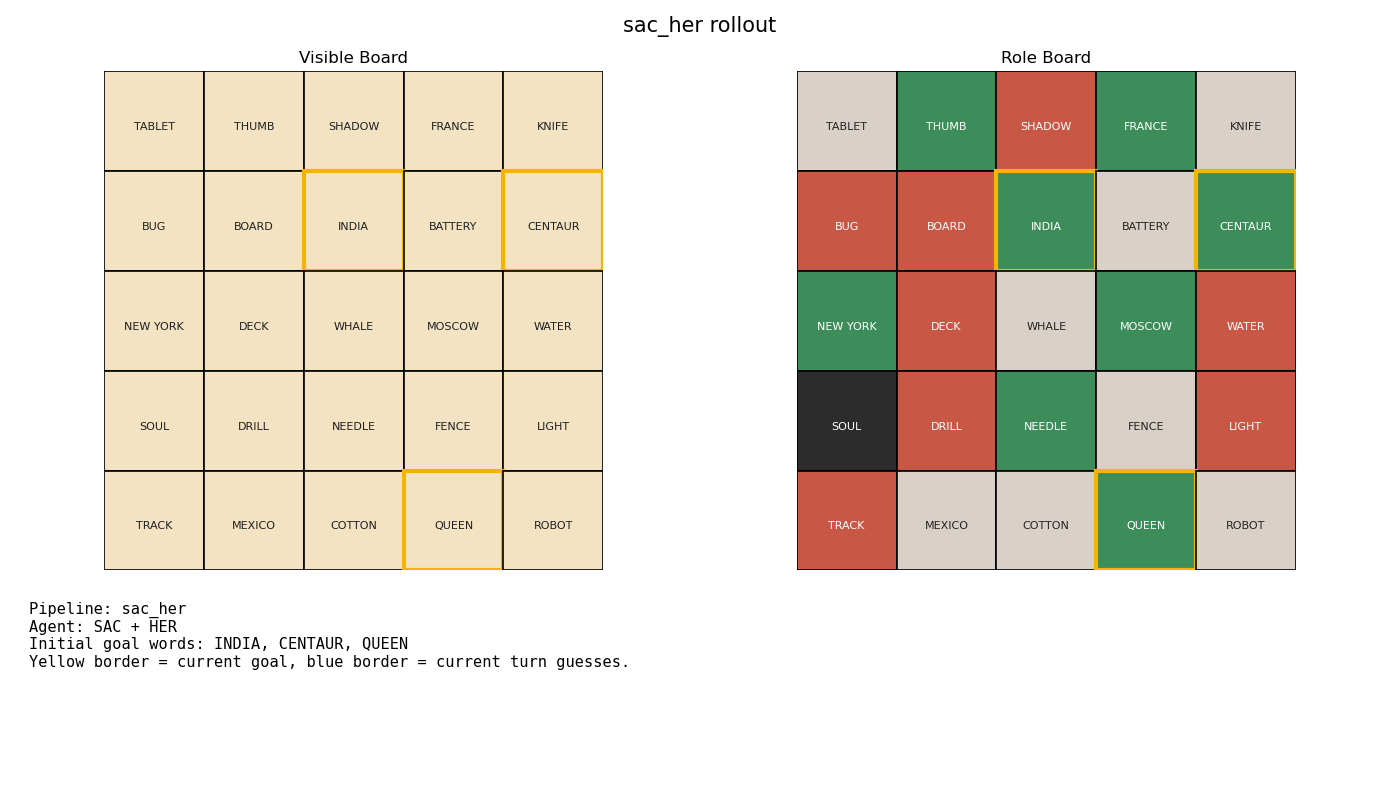

,pipeline,agent,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,sac_her,SAC + HER,32,0.0,1.0,9,-34.988,False,True,notebooks/artifacts/training_pipeline_rollout_...


,step,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,betrap,5,"INDIA, CENTAUR, QUEEN",DECK,opponent,-1.169189,-1.169189,8,False,False
1,2,betrap,5,"INDIA, CENTAUR, QUEEN",LIGHT,opponent,-1.138448,-2.307637,8,False,False
2,3,betrap,5,"INDIA, CENTAUR, QUEEN",ROBOT,neutral,-1.136640,-3.444277,8,False,False
3,4,betrap,5,"INDIA, CENTAUR, QUEEN",TABLET,neutral,-1.127171,-4.571448,8,False,False
4,5,betrap,5,"INDIA, CENTAUR, QUEEN",TRACK,opponent,-1.113370,-5.684818,8,False,False
5,6,betrap,5,"INDIA, CENTAUR, QUEEN",BOARD,opponent,-1.095789,-6.780607,8,False,False
6,7,betrap,5,"INDIA, CENTAUR, QUEEN","NEEDLE, MEXICO","friendly, neutral",-1.086588,-7.867195,7,False,False
7,8,betrap,5,"INDIA, CENTAUR, QUEEN","QUEEN, SHADOW","friendly, opponent",-1.064980,-8.932175,6,False,False
8,9,betrap,5,"THUMB, INDIA, CENTAUR","NEW YORK, SOUL","friendly, assassin",-26.056236,-34.988411,5,False,True


## greedy

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/greedy/greedy_rollout.gif`

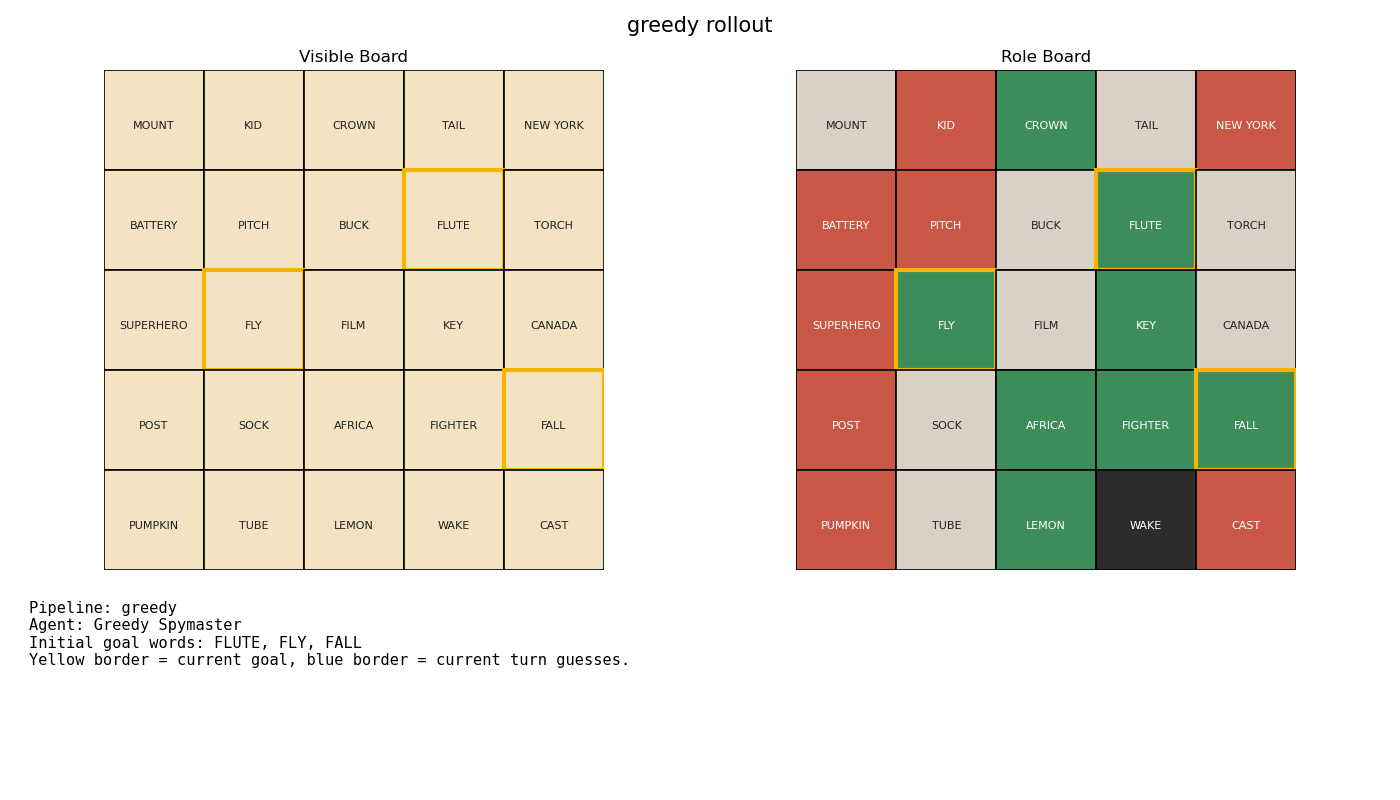

,pipeline,agent,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,greedy,Greedy Spymaster,0,1.0,0.0,8,-7.602,True,False,notebooks/artifacts/training_pipeline_rollout_...


,step,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,squall,1,"FLUTE, FLY, FALL",FALL,friendly,-1.119307,-1.119307,7,False,False
1,2,boatly,1,"FLUTE, FLY, KEY",FLY,friendly,-1.093030,-2.212337,6,False,False
2,3,ulster,1,"FLUTE, KEY, FIGHTER",FIGHTER,friendly,-1.110100,-3.322438,5,False,False
3,4,tidley,1,"FLUTE, KEY, LEMON",KEY,friendly,-1.167198,-4.489635,4,False,False
4,5,croppy,1,"CROWN, FLUTE, LEMON",CROWN,friendly,-1.131783,-5.621418,3,False,False
5,6,afront,1,"FLUTE, AFRICA, LEMON",AFRICA,friendly,-1.131944,-6.753362,2,False,False
6,7,ajowan,1,"FLUTE, LEMON",FLUTE,friendly,-0.952388,-7.705751,1,False,False
7,8,wheeze,1,LEMON,LEMON,friendly,0.104167,-7.601584,0,True,False


## greedy_bc_pretrain

Artifacts saved to `notebooks/artifacts/training_pipeline_rollout_debug/greedy_bc_pretrain/greedy_bc_pretrain_rollout.gif`

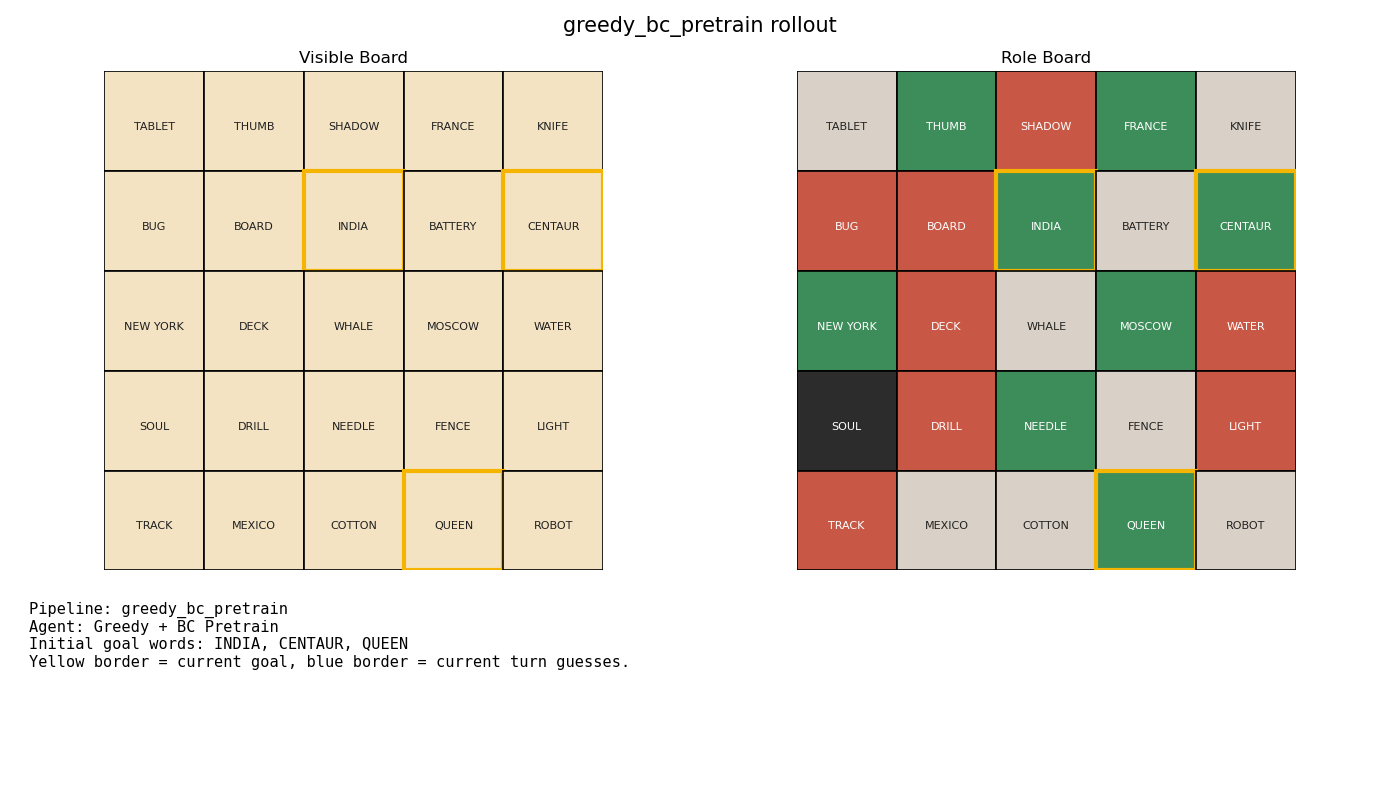

,pipeline,agent,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
0,greedy_bc_pretrain,Greedy + BC Pretrain,32,0.0,0.5,4,-29.7,False,True,notebooks/artifacts/training_pipeline_rollout_...


,step,clue,count,goal_words,guessed_words,guessed_roles,reward,cumulative_reward,friendly_remaining,won,assassin_hit
0,1,gallus,5,"INDIA, CENTAUR, QUEEN",KNIFE,neutral,-1.208375,-1.208375,8,False,False
1,2,gallus,5,"INDIA, CENTAUR, QUEEN",BOARD,opponent,-1.191355,-2.399729,8,False,False
2,3,gallus,5,"INDIA, CENTAUR, QUEEN",ROBOT,neutral,-1.153126,-3.552855,8,False,False
3,4,gallus,5,"INDIA, CENTAUR, QUEEN",SOUL,assassin,-26.147433,-29.700288,8,False,True


In [4]:
runs = {name: run_pipeline_demo(name) for name in PIPELINES}

## Step 4. Organize the Final Conclusions

This table provides an overview of the three pipelines for quick comparison. If you want to switch agents later, you only need to add the corresponding pipeline or replace the builder, and the section below can still be reused.

In [5]:
comparison_df = pd.concat(
    [item["summary_df"] for item in runs.values()], ignore_index=True
)
comparison_df.sort_values(
    ["trace_won", "eval_win_rate", "trace_total_reward"],
    ascending=[False, False, False],
)

,pipeline,agent,demo_transitions,eval_win_rate,eval_assassin_rate,trace_steps,trace_total_reward,trace_won,trace_assassin_hit,gif
1,greedy,Greedy Spymaster,0,1.0,0.0,8,-7.602,True,False,notebooks/artifacts/training_pipeline_rollout_...
2,greedy_bc_pretrain,Greedy + BC Pretrain,32,0.0,0.5,4,-29.700,False,True,notebooks/artifacts/training_pipeline_rollout_...
0,sac_her,SAC + HER,32,0.0,1.0,9,-34.988,False,True,notebooks/artifacts/training_pipeline_rollout_...


## Step 5. If you want to change the agent, where to suggest changes

- Training orchestration: `src/training/pipeline_registry.py`
- Shared env / config / demo collection: `src/training/pipeline_utils.py`
- GIF and rollout visualization: `src/training/rollout_visualizer.py`

As long as the new agent can provide `predict(...)` or `select_action(...)`, the main flow of this notebook usually doesn't need to be changed.